# Six-Face Test: Calibration

Use this notebook to compute the calibration parameters with the data from the `1-dataCapture.ipynb` notebook.

## Setup

In [1]:
from signal_utils import IMUSampleReader, IMUSampleTimeSeriesPlotter
import numpy as np

reader = IMUSampleReader()
captureFiles = [
    "./capture/positive-x-up.csv",
    "./capture/negative-x-up.csv",
    "./capture/positive-y-up.csv",
    "./capture/negative-y-up.csv",
    "./capture/positive-z-up.csv",
    "./capture/negative-z-up.csv",
]
rawOrientations = [reader.read(file) for file in captureFiles]

timeSeriesPlotter = IMUSampleTimeSeriesPlotter()

## Accelerometer 
View accelerometer calibration as an affine transformation (rotation, shear, scaling, translation) applied to the raw sensor data to obtain the true physical values. Consider the linear system:

Ax = b 

Where:
- A: the mean of raw sensor readings in the six static orientations. This is valid since standard deviations are tight overall, as seen in `2-analysis.ipynb`.
- b: true physical values (0 or +-g, depending on the axis and orientation).
- x: transformation matrix obtained with least squares by multiplying the pseudo-inverse of A and b i.e. x = (A^t * A)^(-1) * A^t * b.

Sources: 
- https://cookierobotics.com/061/
- Linear Algebra - Stanley Grossman: 6.2. Approximation by Least Squares

In [2]:
A = np.ones((len(captureFiles), 4))
for i, rawMotionData in enumerate(rawOrientations):
    ax = np.mean(rawMotionData["a"]["x"])  # type: ignore
    ay = np.mean(rawMotionData["a"]["y"])  # type: ignore
    az = np.mean(rawMotionData["a"]["z"])  # type: ignore

    # 1: independent term for bias
    A[i] = [ax, ay, az, 1]
print(f"A = {A}")

G = 9.80665
b = np.zeros((len(captureFiles), 3))
b[0][0] = G
b[1][0] = -G
b[2][1] = G
b[3][1] = -G
b[4][2] = G
b[5][2] = -G
print(f"\nb = {b}")

x = np.linalg.pinv(A) @ b
print(f"\nx = {x}")

A = [[ 1.01286745e+01  3.59638602e-01 -1.39074787e-01  1.00000000e+00]
 [-9.50094318e+00  1.78156346e-01  2.66360134e-01  1.00000000e+00]
 [ 2.15340301e-01  9.99934483e+00  3.45716596e-01  1.00000000e+00]
 [ 4.48391050e-01 -9.66972923e+00 -3.56969945e-02  1.00000000e+00]
 [ 4.64882463e-01  1.33724347e-01  1.02007694e+01  1.00000000e+00]
 [ 2.03726083e-01 -5.97101520e-04 -9.79886913e+00  1.00000000e+00]]

b = [[ 9.80665  0.       0.     ]
 [-9.80665  0.       0.     ]
 [ 0.       9.80665  0.     ]
 [ 0.      -9.80665  0.     ]
 [ 0.       0.       9.80665]
 [ 0.       0.      -9.80665]]

x = [[ 0.99878374 -0.00933288  0.02040961]
 [ 0.01210606  0.99696514 -0.01862394]
 [-0.01313606 -0.00642989  0.98043959]
 [-0.32646267 -0.16230203 -0.1406934 ]]


## Gyroscope

For the gyroscope, I can only substract the stationary bias for now, since I can't produce known angular velocities for calibration. However, another device could be built with my Arduino Uno and a stepper motor in the future.

## Results

In [19]:
calibratedOrientations = []
xT = np.transpose(x)
for rawMotionData in rawOrientations:

    timespan = len(rawMotionData["t"])
    ax = np.zeros(timespan)
    ay = np.zeros(timespan)
    az = np.zeros(timespan)

    for j in range(timespan):
        ax[j] = np.dot(xT[0], np.array([rawMotionData["a"]["x"][j], rawMotionData["a"]["y"][j], rawMotionData["a"]["z"][j], 1]))  # type: ignore
        ay[j] = np.dot(xT[1], np.array([rawMotionData["a"]["x"][j], rawMotionData["a"]["y"][j], rawMotionData["a"]["z"][j], 1]))  # type: ignore
        az[j] = np.dot(xT[2], np.array([rawMotionData["a"]["x"][j], rawMotionData["a"]["y"][j], rawMotionData["a"]["z"][j], 1]))  # type: ignore

    calibratedOrientations.append(
        {
            "t": rawMotionData["t"],
            "a": {
                "x": ax,
                "y": ay,
                "z": az,
            },
            "w": rawMotionData["w"],
        }
    )

### Orientation 1: +X Up

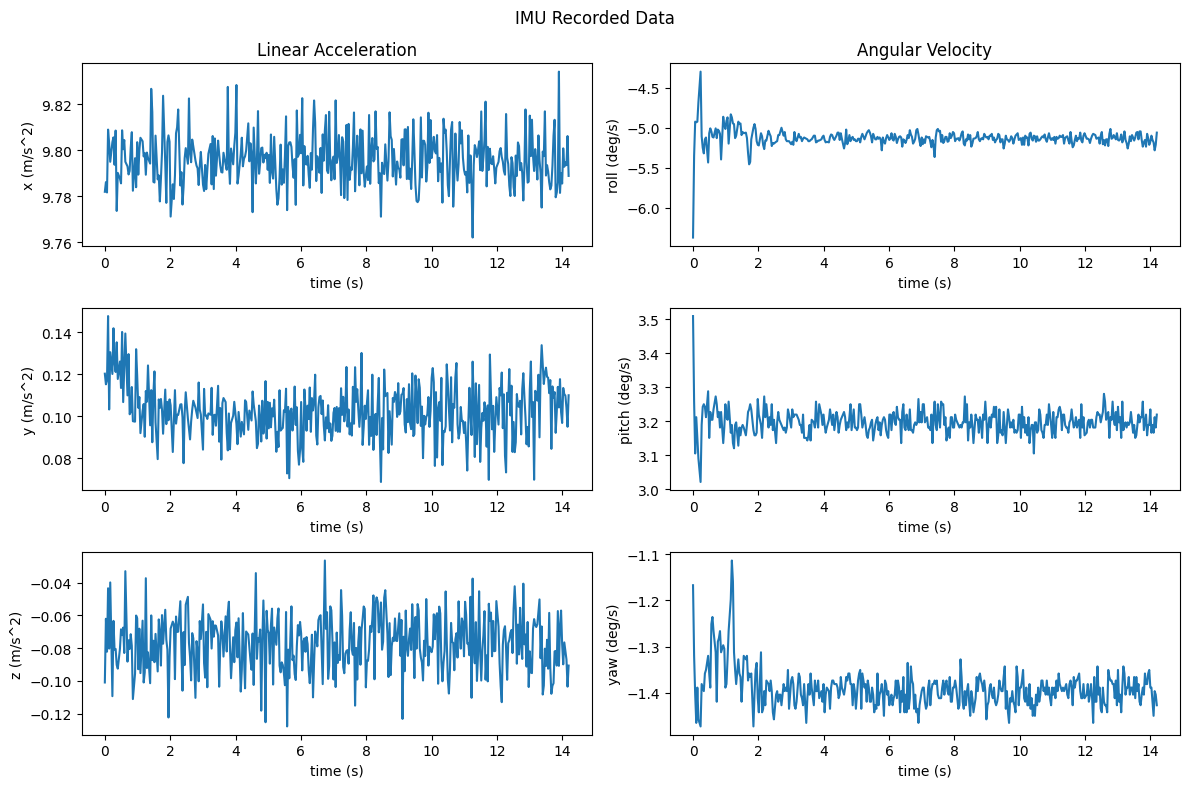

In [20]:
timeSeriesPlotter.plot(calibratedOrientations[0])  # type: ignore

### Orientation 2: -X Up

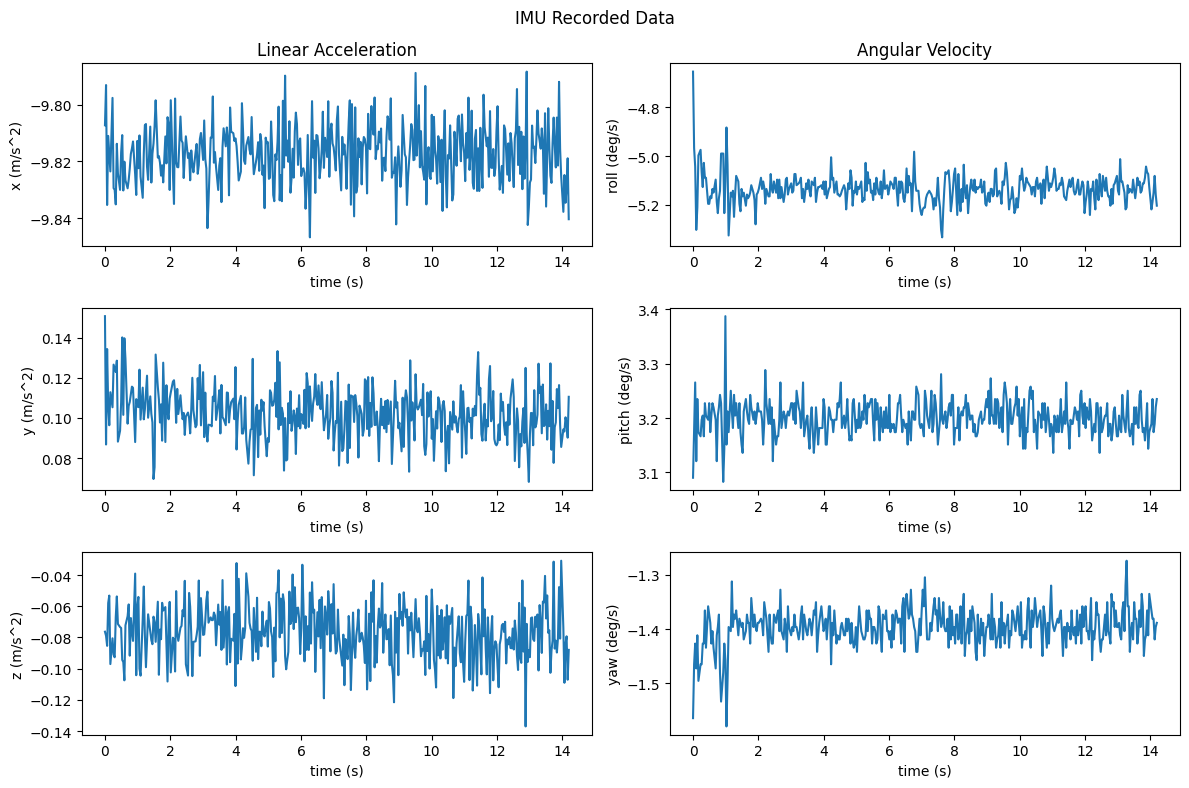

In [21]:
timeSeriesPlotter.plot(calibratedOrientations[1])  # type: ignore

### Orientation 3: +Y Up

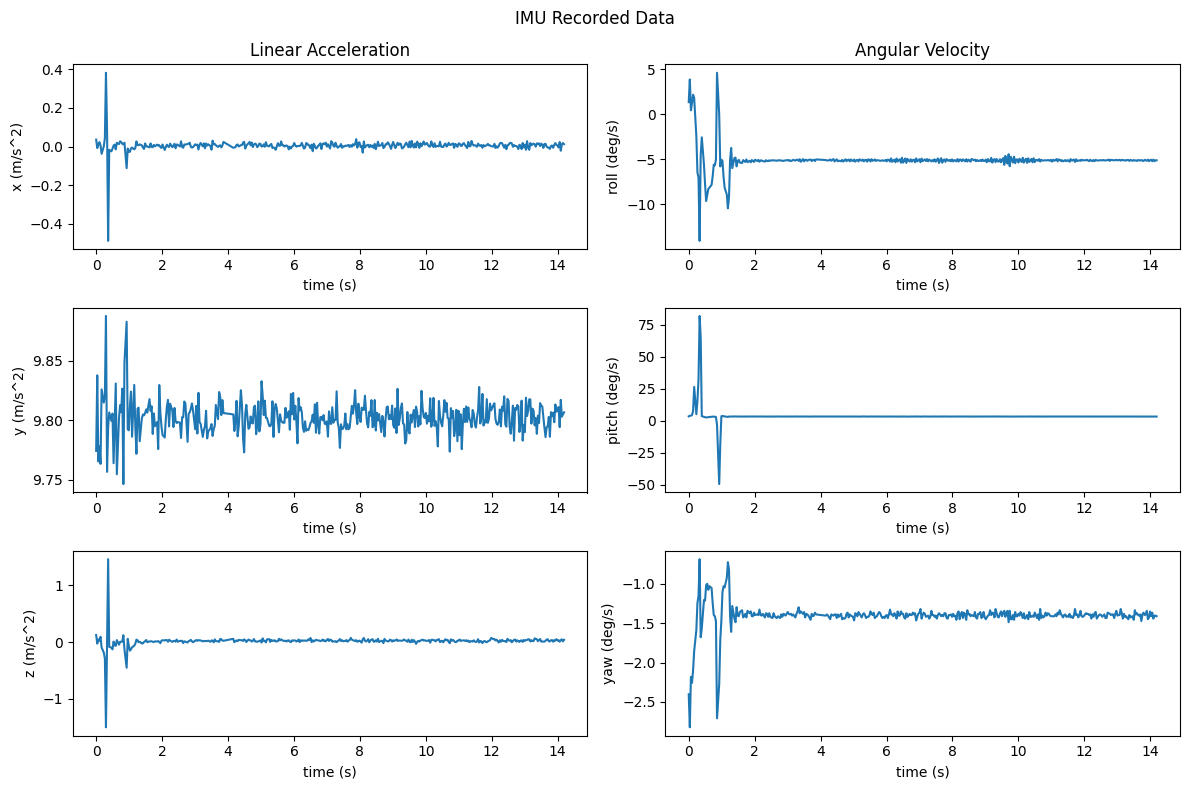

In [22]:
timeSeriesPlotter.plot(calibratedOrientations[2])  # type: ignore

### Orientation 4: -Y Up

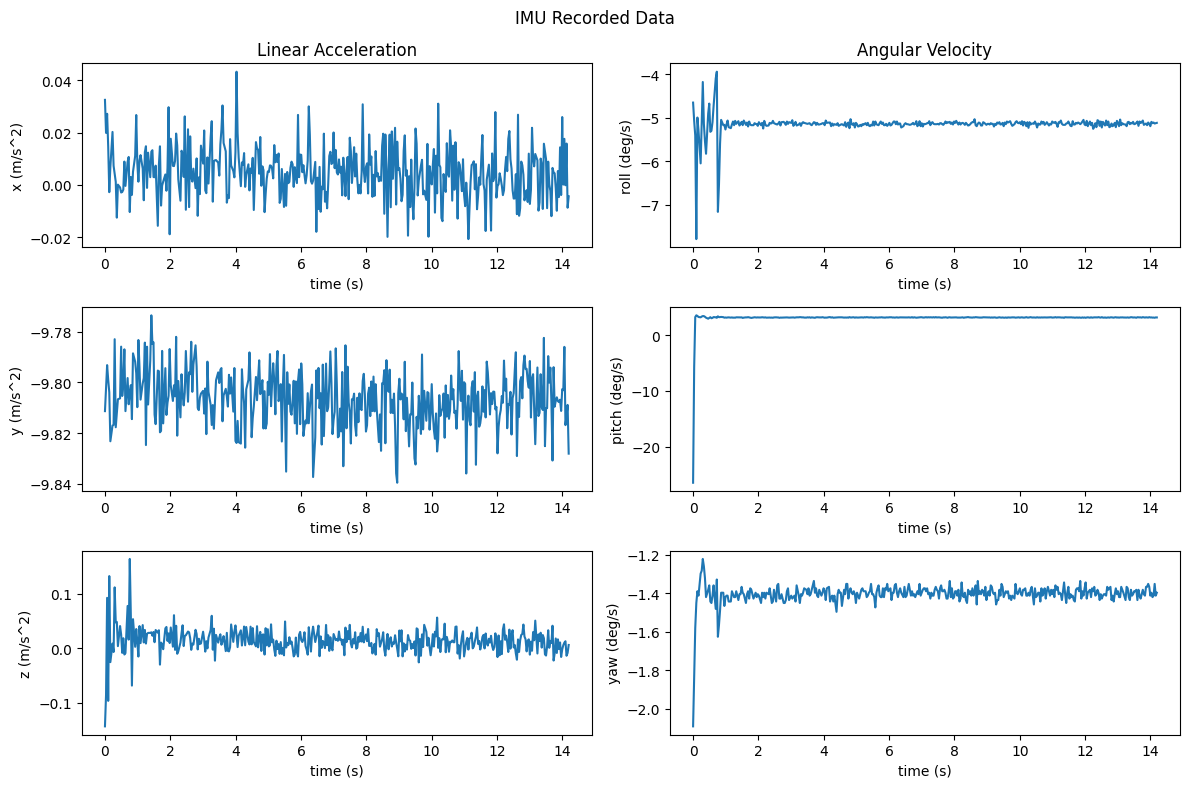

In [23]:
timeSeriesPlotter.plot(calibratedOrientations[3])  # type: ignore

### Orientation 5: +Z Up

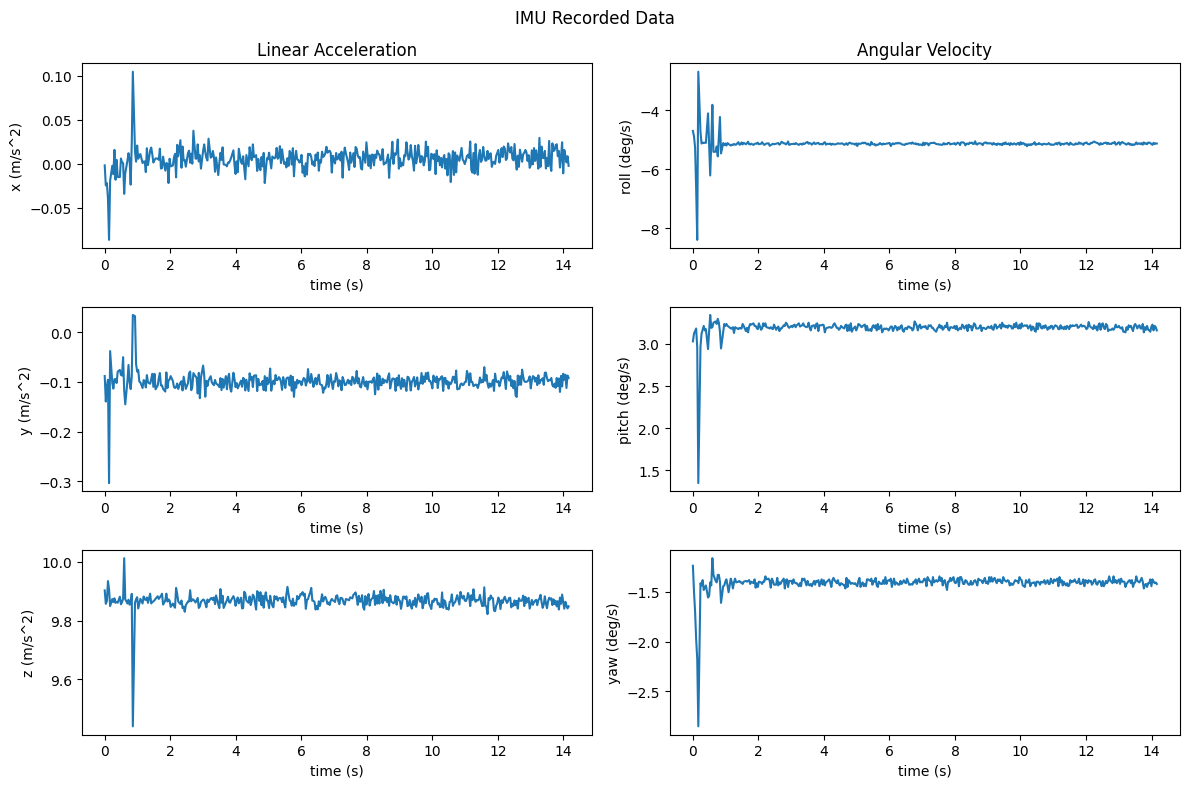

In [24]:
timeSeriesPlotter.plot(calibratedOrientations[4])  # type: ignore

### Orientation 6: -Z Up

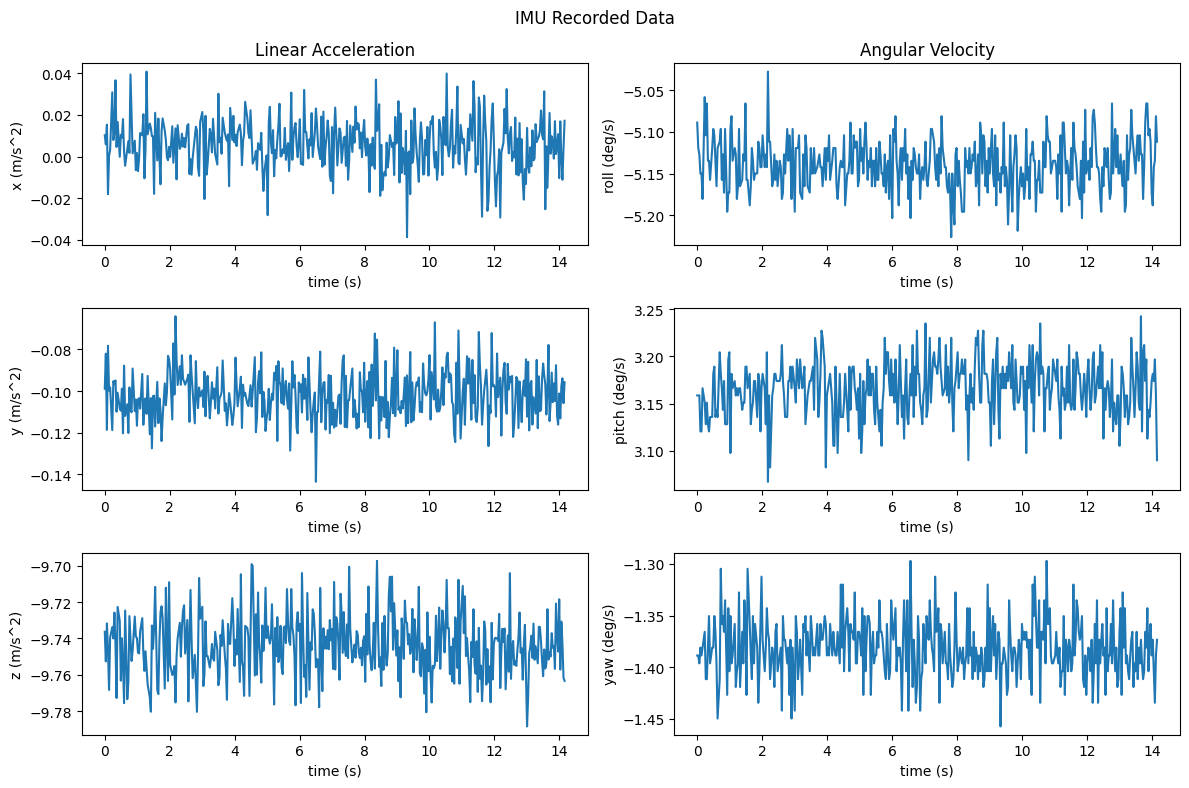

In [25]:
timeSeriesPlotter.plot(calibratedOrientations[5])  # type: ignore